<a target="_blank" href="https://colab.research.google.com/github/AI4Finance-Foundation/FinRL-Tutorials/blob/master/1-Introduction/FinRL_PortfolioAllocation_NeurIPS_2020.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Deep Reinforcement Learning for Stock Trading from Scratch: Portfolio Allocation

Tutorials to use OpenAI DRL to perform portfolio allocation in one Jupyter Notebook | Presented at NeurIPS 2020: Deep RL Workshop

* This blog is based on our paper: FinRL: A Deep Reinforcement Learning Library for Automated Stock Trading in Quantitative Finance, presented at NeurIPS 2020: Deep RL Workshop.
* Check out medium blog for detailed explanations: https://towardsdatascience.com/finrl-for-quantitative-finance-tutorial-for-portfolio-allocation-9b417660c7cd
* Please report any issues to our Github: https://github.com/AI4Finance-Foundation/FinRL/issues
* **Pytorch Version** 



# Content

* [1. Problem Definition](#0)
* [2. Getting Started - Load Python packages](#1)
    * [2.1. Install Packages](#1.1)    
    * [2.2. Check Additional Packages](#1.2)
    * [2.3. Import Packages](#1.3)
    * [2.4. Create Folders](#1.4)
* [3. Download Data](#2)
* [4. Preprocess Data](#3)        
    * [4.1. Technical Indicators](#3.1)
    * [4.2. Perform Feature Engineering](#3.2)
* [5.Build Environment](#4)  
    * [5.1. Training & Trade Data Split](#4.1)
    * [5.2. User-defined Environment](#4.2)   
    * [5.3. Initialize Environment](#4.3)    
* [6.Implement DRL Algorithms](#5)  
* [7.Backtesting Performance](#6)  
    * [7.1. BackTestStats](#6.1)
    * [7.2. BackTestPlot](#6.2)   
    * [7.3. Baseline Stats](#6.3)   
    * [7.3. Compare to Stock Market Index](#6.4)             

<a id='0'></a>
# Part 1. Problem Definition

This problem is to design an automated trading solution for portfolio alloacation. We model the stock trading process as a Markov Decision Process (MDP). We then formulate our trading goal as a maximization problem.

The algorithm is trained using Deep Reinforcement Learning (DRL) algorithms and the components of the reinforcement learning environment are:


* Action: The action space describes the allowed actions that the agent interacts with the
environment. Normally, a ∈ A represents the weight of a stock in the porfolio: a ∈ (-1,1). Assume our stock pool includes N stocks, we can use a list [a<sub>1</sub>, a<sub>2</sub>, ... , a<sub>N</sub>] to determine the weight for each stock in the porfotlio, where a<sub>i</sub> ∈ (-1,1), a<sub>1</sub>+ a<sub>2</sub>+...+a<sub>N</sub>=1. For example, "The weight of AAPL in the portfolio is 10%." is [0.1 , ...].

* Reward function: r(s, a, s′) is the incentive mechanism for an agent to learn a better action. The change of the portfolio value when action a is taken at state s and arriving at new state s',  i.e., r(s, a, s′) = v′ − v, where v′ and v represent the portfolio
values at state s′ and s, respectively

* State: The state space describes the observations that the agent receives from the environment. Just as a human trader needs to analyze various information before executing a trade, so
our trading agent observes many different features to better learn in an interactive environment.

* Environment: Dow 30 consituents


The data of the single stock that we will be using for this case study is obtained from Yahoo Finance API. The data contains Open-High-Low-Close price and volume.


<a id='1'></a>
# Part 2. Getting Started- Load Python Packages

<a id='1.1'></a>
## 2.1. Install all the packages through FinRL library


In [51]:
## install finrl library
#!pip install wrds
#!pip install swig
#!pip install -q condacolab
#import condacolab
#condacolab.install()
#!apt-get update -y -qq && apt-get install -y -qq cmake libopenmpi-dev python3-dev zlib1g-dev libgl1-mesa-glx swig
#!pip install git+https://github.com/AI4Finance-Foundation/FinRL.git


<a id='1.2'></a>
## 2.2. Check if the additional packages needed are present, if not install them. 
* Yahoo Finance API
* pandas
* numpy
* matplotlib
* stockstats
* OpenAI gym
* stable-baselines
* tensorflow
* pyfolio

<a id='1.3'></a>
## 2.3. Import Packages

In [52]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('Agg')
%matplotlib inline
import datetime

from finrl import config
from finrl import config_tickers
from finrl.meta.preprocessor.yahoodownloader import YahooDownloader
from finrl.meta.preprocessor.preprocessors import FeatureEngineer, data_split
from finrl.meta.env_portfolio_allocation.env_portfolio import StockPortfolioEnv
from finrl.agents.stablebaselines3.models import DRLAgent
from finrl.plot import backtest_stats, backtest_plot, get_daily_return, get_baseline,convert_daily_return_to_pyfolio_ts
from finrl.meta.data_processor import DataProcessor
from finrl.meta.data_processors.processor_yahoofinance import YahooFinanceProcessor
import sys
sys.path.append("../FinRL-Library")

In [53]:
import sys
print(sys.executable)


/Users/paolobortolotti/FinRL-Tutorials/.venv/bin/python


<a id='1.4'></a>
## 2.4. Create Folders

In [54]:
import os
if not os.path.exists("./" + config.DATA_SAVE_DIR):
    os.makedirs("./" + config.DATA_SAVE_DIR)
if not os.path.exists("./" + config.TRAINED_MODEL_DIR):
    os.makedirs("./" + config.TRAINED_MODEL_DIR)
if not os.path.exists("./" + config.TENSORBOARD_LOG_DIR):
    os.makedirs("./" + config.TENSORBOARD_LOG_DIR)
if not os.path.exists("./" + config.RESULTS_DIR):
    os.makedirs("./" + config.RESULTS_DIR)

<a id='2'></a>
# Part 3. Download Data
Yahoo Finance is a website that provides stock data, financial news, financial reports, etc. All the data provided by Yahoo Finance is free.
* FinRL uses a class **YahooDownloader** to fetch data from Yahoo Finance API
* Call Limit: Using the Public API (without authentication), you are limited to 2,000 requests per hour per IP (or up to a total of 48,000 requests a day).


In [55]:
  from finrl.meta.preprocessor.yahoodownloader import YahooDownloader

  DJI_2019_2021 = [
      "AAPL", "AMGN", "AXP", "BA",  "CAT", "CRM", "CSCO", "CVX", "DIS", "DOW",
      "GS",   "HD",   "HON", "IBM", "INTC","JNJ", "JPM",  "KO",  "MCD", "MMM",
      "MRK",  "MSFT", "NKE", "PG",  "TRV", "UNH", "V",    "VZ",  "WBA", "WMT",
  ]

  df = YahooDownloader(
      start_date  = "2008-01-01",
      end_date    = "2021-10-31",
      ticker_list = DJI_2019_2021,
  ).fetch_data()

  print(f"Got {df.tic.nunique()} tickers, {len(df):,} rows")
  print(f"Date range: {df.date.min()} to {df.date.max()}")
  print(f"Missing: {set(DJI_2019_2021) - set(df.tic.unique())}")


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%********

Shape of DataFrame:  (98132, 8)
Got 29 tickers, 98,132 rows
Date range: 2008-01-02 to 2021-10-29
Missing: {'WBA'}


In [56]:
#print(config_tickers.DOW_30_TICKER)

In [57]:
df.head()

Price,date,close,high,low,open,volume,tic,day
0,2008-01-02,5.832619,5.994869,5.764067,5.965233,1079178800,AAPL,2
1,2008-01-02,31.283474,31.578856,31.055225,31.283474,7934400,AMGN,2
2,2008-01-02,38.495190,39.460585,38.306636,39.287116,8053700,AXP,2
3,2008-01-02,63.481609,64.375712,63.027225,64.177838,4303000,BA,2
4,2008-01-02,44.030762,45.302499,43.669193,45.233924,6337800,CAT,2


In [58]:
df.shape

(98132, 8)

# Part 4: Preprocess Data
Data preprocessing is a crucial step for training a high quality machine learning model. We need to check for missing data and do feature engineering in order to convert the data into a model-ready state.
* Add technical indicators. In practical trading, various information needs to be taken into account, for example the historical stock prices, current holding shares, technical indicators, etc. In this article, we demonstrate two trend-following technical indicators: MACD and RSI.
* Add turbulence index. Risk-aversion reflects whether an investor will choose to preserve the capital. It also influences one's trading strategy when facing different market volatility level. To control the risk in a worst-case scenario, such as financial crisis of 2007–2008, FinRL employs the financial turbulence index that measures extreme asset price fluctuation.

In [59]:
fe = FeatureEngineer(
                    use_technical_indicator=True,
                    use_turbulence=False,
                    user_defined_feature = False)

df = fe.preprocess_data(df)

Successfully added technical indicators


In [60]:
df.shape

(94041, 16)

In [61]:
df.head()

,date,close,high,low,open,volume,tic,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma
0,2008-01-02,5.832619,5.994869,5.764067,5.965233,1079178800,AAPL,2,0.0,5.837775,5.830156,100.0,-66.666667,100.0,5.832619,5.832619
3483,2008-01-02,31.283474,31.578856,31.055225,31.283474,7934400,AMGN,2,0.0,5.837775,5.830156,100.0,-66.666667,100.0,31.283474,31.283474
6966,2008-01-02,38.495190,39.460585,38.306636,39.287116,8053700,AXP,2,0.0,5.837775,5.830156,100.0,-66.666667,100.0,38.495190,38.495190
10449,2008-01-02,63.481609,64.375712,63.027225,64.177838,4303000,BA,2,0.0,5.837775,5.830156,100.0,-66.666667,100.0,63.481609,63.481609
13932,2008-01-02,44.030762,45.302499,43.669193,45.233924,6337800,CAT,2,0.0,5.837775,5.830156,100.0,-66.666667,100.0,44.030762,44.030762


In [62]:
df.tail()

,date,close,high,low,open,volume,tic,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma
80108,2021-10-29,127.477318,127.914150,126.612550,126.737361,6239500,PG,4,0.183559,128.531963,123.134401,53.991095,87.832896,8.053568,125.856283,126.588198
83591,2021-10-29,147.411072,148.840466,147.209489,148.556421,1314100,TRV,4,1.364511,149.995971,138.616595,55.691902,130.771363,19.943269,143.288143,143.790369
87074,2021-10-29,425.691498,426.542024,418.841159,420.089201,2497800,UNH,4,12.175226,437.040940,348.492885,67.009726,145.393410,52.406261,386.226735,385.391957
90557,2021-10-29,39.754009,39.799020,39.318882,39.386402,17763200,VZ,4,-0.144883,40.844667,38.384323,46.684979,-29.652760,8.097729,39.815880,40.325074
94040,2021-10-29,46.899067,47.112500,46.315262,46.425116,22022700,WMT,4,0.581378,47.881658,41.832964,59.710670,130.833099,35.502501,44.698910,45.535952


## Add covariance matrix as states

In [63]:
# add covariance matrix as states
df=df.sort_values(['date','tic'],ignore_index=True)
df.index = df.date.factorize()[0]

cov_list = []
return_list = []

# look back is one year
lookback=252
for i in range(lookback,len(df.index.unique())):
  data_lookback = df.loc[i-lookback:i,:]
  price_lookback=data_lookback.pivot_table(index = 'date',columns = 'tic', values = 'close')
  return_lookback = price_lookback.pct_change().dropna()
  return_list.append(return_lookback)

  covs = return_lookback.cov().values 
  cov_list.append(covs)

  
df_cov = pd.DataFrame({'date':df.date.unique()[lookback:],'cov_list':cov_list,'return_list':return_list})
df = df.merge(df_cov, on='date')
df = df.sort_values(['date','tic']).reset_index(drop=True)


In [69]:
return_list

[tic             AAPL      AMGN       AXP        BA       CAT       CRM  \
 date                                                                     
 2008-01-03  0.000462 -0.019528 -0.012343  0.004156 -0.003539  0.011612   
 2008-01-04 -0.076335 -0.019479 -0.025194 -0.013337 -0.026286 -0.034766   
 2008-01-07 -0.013385  0.013170  0.004477 -0.034374  0.002919 -0.018688   
 2008-01-08 -0.035971  0.020709 -0.028565 -0.035719 -0.022989 -0.052978   
 2008-01-09  0.047592  0.028491  0.023566  0.004881  0.001191 -0.006764   
 ...              ...       ...       ...       ...       ...       ...   
 2008-12-24 -0.015513 -0.003661  0.000557 -0.000747  0.018964 -0.000950   
 2008-12-26  0.009054  0.003499 -0.003339  0.010219  0.019328 -0.004120   
 2008-12-29  0.009323 -0.008543 -0.011725 -0.013324 -0.008895 -0.015595   
 2008-12-30 -0.003694  0.012661  0.016949  0.031508  0.031176  0.000970   
 2008-12-31 -0.010893  0.002778  0.030555  0.034425  0.023133  0.033915   
 
 tic             CSCO  

In [65]:
return_lookback

tic,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,GS,...,MCD,MMM,MRK,MSFT,NKE,PG,TRV,UNH,VZ,WMT
date,,,,,,,,,,,,,,,,,,,,,
2020-10-30,-0.056018,-0.004040,0.001867,-0.026300,0.015387,-0.020536,0.005884,0.010174,-0.002386,-0.004738,...,-0.009072,0.009339,-0.008960,-0.010991,-0.022627,-0.003417,-0.014290,0.004808,0.004052,-0.008362
2020-11-02,-0.000827,0.015073,0.023674,0.029157,0.039605,0.000775,0.000000,0.038130,-0.009237,0.006136,...,-0.002066,0.018630,0.019944,-0.000691,0.019237,0.010212,0.026593,0.022809,0.012459,0.011892
2020-11-03,0.015354,-0.000681,0.030943,0.033984,0.027072,0.020133,0.021727,-0.005683,0.032382,0.040641,...,0.019947,0.015773,0.002738,0.020264,0.017975,0.019639,0.019529,0.029638,0.000867,0.016952
2020-11-04,0.040836,0.046669,0.001142,-0.013147,-0.074304,0.057395,-0.002999,0.000418,0.008466,-0.000303,...,-0.008902,-0.032324,0.048102,0.048249,0.022072,-0.004107,-0.023271,0.103345,-0.009177,-0.005743
2020-11-05,0.035494,0.007120,0.017739,0.036009,0.050635,0.037808,0.018048,0.005156,0.015112,0.025724,...,0.006702,0.018981,-0.001984,0.031887,0.018533,0.012372,0.033306,-0.000451,0.016253,0.010637
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2021-10-25,-0.000336,-0.007695,-0.025497,-0.000470,0.007775,0.004649,0.000544,0.009308,0.015288,0.001038,...,-0.004613,0.008850,0.006284,-0.003331,0.004527,0.000142,-0.004865,0.000735,-0.006612,0.011595
2021-10-26,0.004575,0.005057,-0.007460,-0.014375,-0.012710,0.004048,0.012151,0.002196,0.000174,0.006896,...,-0.003876,-0.001316,0.007225,0.006425,-0.002619,0.014200,-0.007117,0.011457,0.009509,-0.008730
2021-10-27,-0.003148,-0.010063,-0.016137,-0.015252,-0.017582,0.000136,0.006630,-0.017791,-0.014473,-0.015852,...,0.026690,-0.021519,-0.008632,0.042114,-0.008792,-0.007140,-0.004051,-0.002551,-0.008478,-0.008202


In [71]:
df_cov["return_list"].head()

0    tic             AAPL      AMGN       AXP      ...
1    tic             AAPL      AMGN       AXP      ...
2    tic             AAPL      AMGN       AXP      ...
3    tic             AAPL      AMGN       AXP      ...
4    tic             AAPL      AMGN       AXP      ...
Name: return_list, dtype: object

In [67]:
df.shape

(87237, 18)

In [68]:
df.head()

,date,close,high,low,open,volume,tic,day,macd,boll_ub,boll_lb,rsi_30,cci_30,dx_30,close_30_sma,close_60_sma,cov_list,return_list
0,2008-12-31,2.554989,2.626535,2.554690,2.573550,607541200,AAPL,2,-0.081679,3.059025,2.426822,42.254775,-80.846757,16.129910,2.718785,2.829641,"[[0.001348968084189407, 0.0004284121222019101,...",tic AAPL AMGN AXP ...
1,2008-12-31,38.768688,39.084209,38.305479,38.339044,6287200,AMGN,2,0.145253,39.572530,37.854750,51.060611,51.895342,10.432181,38.044558,37.623642,"[[0.001348968084189407, 0.0004284121222019101,...",tic AAPL AMGN AXP ...
2,2008-12-31,14.178247,14.331113,13.689079,13.734938,9625600,AXP,2,-0.909757,18.132131,12.310984,42.554830,-74.811912,25.740172,15.309454,17.130079,"[[0.001348968084189407, 0.0004284121222019101,...",tic AAPL AMGN AXP ...
3,2008-12-31,32.005890,32.290921,31.128298,31.195806,5443100,BA,2,-0.279801,32.174388,28.867828,47.440243,157.922094,5.791945,30.327212,32.389915,"[[0.001348968084189407, 0.0004284121222019101,...",tic AAPL AMGN AXP ...
4,2008-12-31,28.586323,28.861499,27.965578,27.965578,6277400,CAT,2,0.632975,29.300219,24.576704,51.205325,98.904855,26.480735,25.768002,25.511226,"[[0.001348968084189407, 0.0004284121222019101,...",tic AAPL AMGN AXP ...


<a id='4'></a>
# Part 5. Design Environment
Considering the stochastic and interactive nature of the automated stock trading tasks, a financial task is modeled as a **Markov Decision Process (MDP)** problem. The training process involves observing stock price change, taking an action and reward's calculation to have the agent adjusting its strategy accordingly. By interacting with the environment, the trading agent will derive a trading strategy with the maximized rewards as time proceeds.

Our trading environments, based on OpenAI Gym framework, simulate live stock markets with real market data according to the principle of time-driven simulation.


## Training data split: 2009-01-01 to 2020-07-01

In [ ]:
train = data_split(df, '2009-01-01','2020-07-01')
#trade = data_split(df, '2020-01-01', config.END_DATE)

In [ ]:
train.head()

## Environment for Portfolio Allocation


In [ ]:
stock_dimension = len(train.tic.unique())
state_space = stock_dimension
print(f"Stock Dimension: {stock_dimension}, State Space: {state_space}")


In [ ]:
env_kwargs = {
    "hmax": 100, 
    "initial_amount": 1000000, 
    "transaction_cost_pct": 0.001, 
    "state_space": state_space, 
    "stock_dim": stock_dimension, 
    "tech_indicator_list": config.INDICATORS, 
    "action_space": stock_dimension, 
    "reward_scaling": 1e-4
    
}

e_train_gym = StockPortfolioEnv(df = train, **env_kwargs)

In [ ]:
env_train, _ = e_train_gym.get_sb_env()
print(type(env_train))

<a id='5'></a>
# Part 6: Implement DRL Algorithms
* The implementation of the DRL algorithms are based on **OpenAI Baselines** and **Stable Baselines**. Stable Baselines is a fork of OpenAI Baselines, with a major structural refactoring, and code cleanups.
* FinRL library includes fine-tuned standard DRL algorithms, such as DQN, DDPG,
Multi-Agent DDPG, PPO, SAC, A2C and TD3. We also allow users to
design their own DRL algorithms by adapting these DRL algorithms.

In [ ]:
# initialize
agent = DRLAgent(env = env_train)

### Model 1: **A2C**


In [ ]:
agent = DRLAgent(env = env_train)

A2C_PARAMS = {"n_steps": 5, "ent_coef": 0.005, "learning_rate": 0.0002}
model_a2c = agent.get_model(model_name="a2c",model_kwargs = A2C_PARAMS)

In [ ]:
trained_a2c = agent.train_model(model=model_a2c, 
                                tb_log_name='a2c',
                                total_timesteps=50000)

In [ ]:
trained_a2c.save('./trained_models/trained_a2c.zip')

### Model 2: **PPO**


In [105]:
agent = DRLAgent(env=env_train)

PPO_PARAMS = {
  "n_steps":       512,
  "ent_coef":      0.02,
  "learning_rate": 3e-4,
  "batch_size":    128,
  "clip_range":    0.3,
  # seed removed from here
}

model_ppo = agent.get_model(
  "ppo",
  model_kwargs=PPO_PARAMS,
  seed=42,                  # <- pass it here
)


{'n_steps': 512, 'ent_coef': 0.02, 'learning_rate': 0.0003, 'batch_size': 128, 'clip_range': 0.3}
Using cpu device


In [113]:
trained_ppo = agent.train_model(model=model_ppo, 
                             tb_log_name='ppo',
                             total_timesteps=80000)

--------------------------------------
| time/              |               |
|    fps             | 726           |
|    iterations      | 1             |
|    time_elapsed    | 0             |
|    total_timesteps | 512           |
| train/             |               |
|    reward          | 1.6371409e+06 |
|    reward_max      | 1.6400335e+06 |
|    reward_mean     | 1.2797575e+06 |
|    reward_min      | 742244.1      |
--------------------------------------
-------------------------------------------
| time/                   |               |
|    fps                  | 858           |
|    iterations           | 2             |
|    time_elapsed         | 1             |
|    total_timesteps      | 1024          |
| train/                  |               |
|    approx_kl            | 0.0           |
|    clip_fraction        | 0             |
|    clip_range           | 0.3           |
|    entropy_loss         | -38.3         |
|    explained_variance   | -1.19e-07     |
|   

In [114]:
trained_ppo.save('./trained_models/trained_ppo.zip')

### Model 3: **DDPG**


In [ ]:
agent = DRLAgent(env = env_train)
DDPG_PARAMS = {"batch_size": 128, "buffer_size": 50000, "learning_rate": 0.001}


model_ddpg = agent.get_model("ddpg",model_kwargs = DDPG_PARAMS)

In [ ]:
trained_ddpg = agent.train_model(model=model_ddpg, 
                             tb_log_name='ddpg',
                             total_timesteps=50000)

In [ ]:
trained_ddpg.save('./trained_models/trained_ddpg.zip')

### Model 4: **SAC**


In [ ]:
agent = DRLAgent(env = env_train)
SAC_PARAMS = {
    "batch_size": 128,
    "buffer_size": 100000,
    "learning_rate": 0.0003,
    "learning_starts": 100,
    "ent_coef": "auto_0.1",
}

model_sac = agent.get_model("sac",model_kwargs = SAC_PARAMS)

In [ ]:
trained_sac = agent.train_model(model=model_sac, 
                             tb_log_name='sac',
                             total_timesteps=50000)

In [ ]:
trained_sac.save('./trained_models/trained_sac.zip')

### Model 5: **TD3**


In [119]:
agent = DRLAgent(env = env_train)
TD3_PARAMS = {"batch_size": 100, 
              "buffer_size": 1000000, 
              "learning_rate": 0.001}

model_td3 = agent.get_model("td3",model_kwargs = TD3_PARAMS)

{'batch_size': 100, 'buffer_size': 1000000, 'learning_rate': 0.001}
Using cpu device


/Users/paolobortolotti/FinRL-Tutorials/.venv/lib/python3.12/site-packages/stable_baselines3/common/buffers.py:242: UserWarning: This system does not have apparently enough memory to store the complete replay buffer 7.68GB > 1.43GB
  warnings.warn(


In [120]:
trained_td3 = agent.train_model(model=model_td3, 
                             tb_log_name='td3',
                             total_timesteps=30000)

Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging Error: 'rollout_buffer'
Logging 

In [121]:
trained_td3.save('./trained_models/trained_td3.zip')

## Trading
Assume that we have $1,000,000 initial capital at 2019-01-01. We use the A2C model to trade Dow jones 30 stocks.

In [122]:
trade = data_split(df,'2020-07-01', '2021-10-31')
e_trade_gym = StockPortfolioEnv(df = trade, **env_kwargs)


In [123]:
trade.shape

(9099, 18)

In [117]:
import os, time
print("file mtime:", time.ctime(os.path.getmtime('./trained_models/trained_ppo.zip')))
print("num_timesteps in memory:", trained_ppo.num_timesteps)
print("id(trained_ppo):", id(trained_ppo))


file mtime: Sun May 17 22:58:25 2026
num_timesteps in memory: 80384
id(trained_ppo): 6355513856


In [124]:
df_daily_return, df_actions = DRLAgent.DRL_prediction(model=model_td3,
                        environment = e_trade_gym)

begin_total_asset:1000000
end_total_asset:1468253.4551412375
Sharpe:  2.1792817173872003
hit end!


In [125]:
#df_daily_return, df_actions = DRLAgent.DRL_prediction(model=trained_a2c,
#                        environment = e_trade_gym)

In [75]:
df_daily_return.head()

,date,daily_return
0,2020-07-01,0.000000
1,2020-07-02,0.003786
2,2020-07-06,0.015466
3,2020-07-07,-0.013478
4,2020-07-08,0.005776


In [76]:
df_daily_return.to_csv('df_daily_return.csv')

In [77]:
df_actions.head()

,AAPL,AMGN,AXP,BA,CAT,CRM,CSCO,CVX,DIS,GS,...,MCD,MMM,MRK,MSFT,NKE,PG,TRV,UNH,VZ,WMT
date,,,,,,,,,,,,,,,,,,,,,
2020-07-01,0.037037,0.037037,0.037037,0.037037,0.037037,0.037037,0.037037,0.037037,0.037037,0.037037,...,0.037037,0.037037,0.037037,0.037037,0.037037,0.037037,0.037037,0.037037,0.037037,0.037037
2020-07-02,0.037068,0.037036,0.037377,0.036915,0.037117,0.036915,0.037221,0.036915,0.037177,0.036915,...,0.036915,0.036915,0.036927,0.036973,0.036966,0.036921,0.036915,0.037204,0.036915,0.037188
2020-07-06,0.037059,0.037030,0.037389,0.036916,0.037128,0.036916,0.037215,0.036916,0.037187,0.036916,...,0.036916,0.036916,0.036930,0.036952,0.036958,0.036916,0.036916,0.037199,0.036916,0.037184
2020-07-07,0.037130,0.037024,0.037252,0.036905,0.037009,0.036931,0.037309,0.036905,0.037044,0.036905,...,0.036905,0.036936,0.036905,0.037139,0.037021,0.036958,0.036905,0.037222,0.036905,0.037219
2020-07-08,0.037011,0.037042,0.037344,0.036907,0.037116,0.036907,0.037127,0.036907,0.037146,0.036907,...,0.036907,0.036999,0.037119,0.036907,0.036967,0.036941,0.036907,0.037165,0.036907,0.037180


In [78]:
df_actions.to_csv('df_actions.csv')

<a id='6'></a>
# Part 7: Backtest Our Strategy
Backtesting plays a key role in evaluating the performance of a trading strategy. Automated backtesting tool is preferred because it reduces the human error. We usually use the Quantopian pyfolio package to backtest our trading strategies. It is easy to use and consists of various individual plots that provide a comprehensive image of the performance of a trading strategy.

<a id='6.1'></a>
## 7.1 BackTestStats
pass in df_account_value, this information is stored in env class


In [79]:
from pyfolio import timeseries
DRL_strat = convert_daily_return_to_pyfolio_ts(df_daily_return)
perf_func = timeseries.perf_stats 
perf_stats_all = perf_func( returns=DRL_strat, 
                              factor_returns=DRL_strat, 
                                positions=None, transactions=None, turnover_denom="AGB")

In [80]:
print("==============DRL Strategy Stats===========")
perf_stats_all

==============DRL Strategy Stats===========


Annual return          0.306372
Cumulative returns     0.429607
Annual volatility      0.135555
Sharpe ratio           2.040179
Calmar ratio           3.634458
Stability              0.925429
Max drawdown          -0.084297
Omega ratio            1.404425
Sortino ratio          3.105982
Skew                  -0.182033
Kurtosis               1.356071
Tail ratio             1.090406
Daily value at risk   -0.015981
Alpha                  0.000000
Beta                   1.000000
dtype: float64

In [81]:
#baseline stats
print("==============Get Baseline Stats===========")
baseline_df = get_baseline(
        ticker="^DJI", 
        start = df_daily_return.loc[0,'date'],
        end = df_daily_return.loc[len(df_daily_return)-1,'date'])

stats = backtest_stats(baseline_df, value_col_name = 'close')

[*********************100%***********************]  1 of 1 completed

==============Get Baseline Stats===========
Shape of DataFrame:  (336, 8)
Annual return          0.279047
Cumulative returns     0.388402
Annual volatility      0.139129
Sharpe ratio           1.844560
Calmar ratio           3.124551
Stability              0.918675
Max drawdown          -0.089308
Omega ratio            1.358960
Sortino ratio          2.734872
Skew                        NaN
Kurtosis                    NaN
Tail ratio             1.052781
Daily value at risk   -0.016510
dtype: float64


<a id='6.2'></a>
## 7.2 BackTestPlot

[*********************100%***********************]  1 of 1 completed

Shape of DataFrame:  (337, 8)



/Users/paolobortolotti/FinRL-Tutorials/.venv/lib/python3.12/site-packages/pyfolio/plotting.py:670: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '30.637%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2020-07-01
End date,2021-10-29
Total months,16
,Backtest
Annual return,30.637%
Cumulative returns,42.961%
Annual volatility,13.556%
Sharpe ratio,2.04
Calmar ratio,3.63
Stability,0.93
Max drawdown,-8.43%


Worst drawdown periods,Net drawdown in %,Peak date,Valley date,Recovery date,Duration
0,8.43,2020-09-02,2020-10-28,2020-11-09,49
1,4.52,2021-08-16,2021-09-21,2021-10-20,48
2,3.95,2021-01-21,2021-01-29,2021-02-08,13
3,3.77,2021-06-04,2021-06-18,2021-07-01,20
4,3.14,2021-02-24,2021-03-04,2021-03-10,11


/Users/paolobortolotti/FinRL-Tutorials/.venv/lib/python3.12/site-packages/pyfolio/plotting.py:1407: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Daily", "Weekly", "Monthly"])


Stress Events,mean,min,max
Covid,0.11%,-3.24%,3.70%


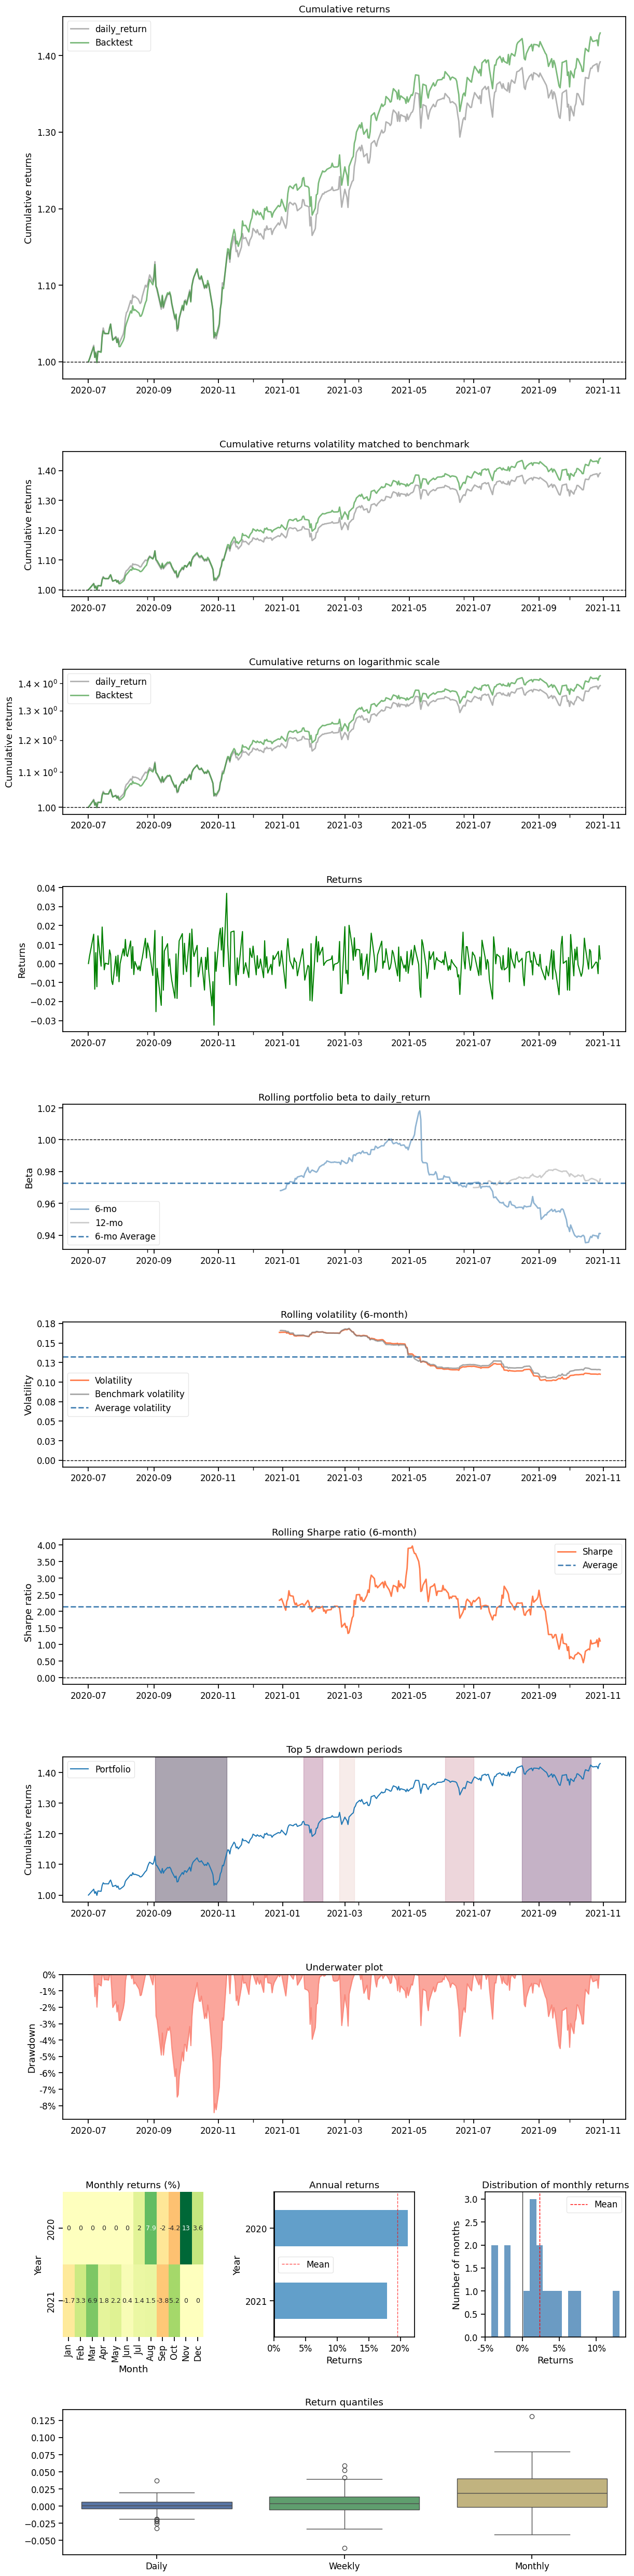

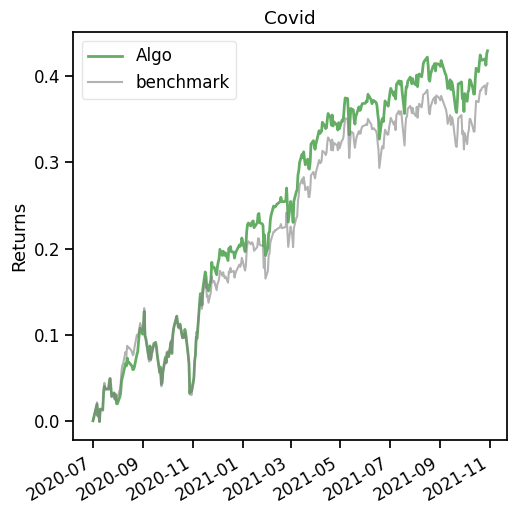

In [82]:
import pyfolio
%matplotlib inline

baseline_df = get_baseline(
        ticker='^DJI', start=df_daily_return.loc[0,'date'], end='2021-11-01'
    )

baseline_returns = get_daily_return(baseline_df, value_col_name="close")

with pyfolio.plotting.plotting_context(font_scale=1.1):
        pyfolio.create_full_tear_sheet(returns = DRL_strat,
                                       benchmark_rets=baseline_returns, set_context=False)

## Min-Variance Portfolio Allocation

In [ ]:
%pip install PyPortfolioOpt

In [ ]:
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import risk_models

In [ ]:
unique_tic = trade.tic.unique()
unique_trade_date = trade.date.unique()

In [ ]:
df.head()

In [ ]:
#calculate_portfolio_minimum_variance
portfolio = pd.DataFrame(index = range(1), columns = unique_trade_date)
initial_capital = 1000000
portfolio.loc[0,unique_trade_date[0]] = initial_capital

for i in range(len( unique_trade_date)-1):
    df_temp = df[df.date==unique_trade_date[i]].reset_index(drop=True)
    df_temp_next = df[df.date==unique_trade_date[i+1]].reset_index(drop=True)
    #Sigma = risk_models.sample_cov(df_temp.return_list[0])
    #calculate covariance matrix
    Sigma = df_temp.return_list[0].cov()
    #portfolio allocation
    ef_min_var = EfficientFrontier(None, Sigma,weight_bounds=(0, 0.1))
    #minimum variance
    raw_weights_min_var = ef_min_var.min_volatility()
    #get weights
    cleaned_weights_min_var = ef_min_var.clean_weights()
    
    #current capital
    cap = portfolio.iloc[0, i]
    #current cash invested for each stock
    current_cash = [element * cap for element in list(cleaned_weights_min_var.values())]
    # current held shares
    current_shares = list(np.array(current_cash)
                                      / np.array(df_temp.close))
    # next time period price
    next_price = np.array(df_temp_next.close)
    ##next_price * current share to calculate next total account value 
    portfolio.iloc[0, i+1] = np.dot(current_shares, next_price)
    
portfolio=portfolio.T
portfolio.columns = ['account_value']

In [ ]:
portfolio.head()

In [ ]:
a2c_cumpod =(df_daily_return.daily_return+1).cumprod()-1

In [ ]:
min_var_cumpod =(portfolio.account_value.pct_change()+1).cumprod()-1

In [ ]:
dji_cumpod =(baseline_returns+1).cumprod()-1

## Plotly: DRL, Min-Variance, DJIA

In [ ]:
%pip install plotly

In [ ]:
from datetime import datetime as dt

import matplotlib.pyplot as plt
import plotly
import plotly.graph_objs as go

In [ ]:
time_ind = pd.Series(df_daily_return.date)

In [ ]:
trace0_portfolio = go.Scatter(x = time_ind, y = a2c_cumpod, mode = 'lines', name = 'A2C (Portfolio Allocation)')

trace1_portfolio = go.Scatter(x = time_ind, y = dji_cumpod, mode = 'lines', name = 'DJIA')
trace2_portfolio = go.Scatter(x = time_ind, y = min_var_cumpod, mode = 'lines', name = 'Min-Variance')
#trace3_portfolio = go.Scatter(x = time_ind, y = ddpg_cumpod, mode = 'lines', name = 'DDPG')
#trace4_portfolio = go.Scatter(x = time_ind, y = addpg_cumpod, mode = 'lines', name = 'Adaptive-DDPG')
#trace5_portfolio = go.Scatter(x = time_ind, y = min_cumpod, mode = 'lines', name = 'Min-Variance')

#trace4 = go.Scatter(x = time_ind, y = addpg_cumpod, mode = 'lines', name = 'Adaptive-DDPG')

#trace2 = go.Scatter(x = time_ind, y = portfolio_cost_minv, mode = 'lines', name = 'Min-Variance')
#trace3 = go.Scatter(x = time_ind, y = spx_value, mode = 'lines', name = 'SPX')

In [ ]:
fig = go.Figure()
fig.add_trace(trace0_portfolio)

fig.add_trace(trace1_portfolio)

fig.add_trace(trace2_portfolio)



fig.update_layout(
    legend=dict(
        x=0,
        y=1,
        traceorder="normal",
        font=dict(
            family="sans-serif",
            size=15,
            color="black"
        ),
        bgcolor="White",
        bordercolor="white",
        borderwidth=2
        
    ),
)
#fig.update_layout(legend_orientation="h")
fig.update_layout(title={
        #'text': "Cumulative Return using FinRL",
        'y':0.85,
        'x':0.5,
        'xanchor': 'center',
        'yanchor': 'top'})
#with Transaction cost
#fig.update_layout(title =  'Quarterly Trade Date')
fig.update_layout(
#    margin=dict(l=20, r=20, t=20, b=20),

    paper_bgcolor='rgba(1,1,0,0)',
    plot_bgcolor='rgba(1, 1, 0, 0)',
    #xaxis_title="Date",
    yaxis_title="Cumulative Return",
xaxis={'type': 'date', 
       'tick0': time_ind[0], 
        'tickmode': 'linear', 
       'dtick': 86400000.0 *80}

)
fig.update_xaxes(showline=True,linecolor='black',showgrid=True, gridwidth=1, gridcolor='LightSteelBlue',mirror=True)
fig.update_yaxes(showline=True,linecolor='black',showgrid=True, gridwidth=1, gridcolor='LightSteelBlue',mirror=True)
fig.update_yaxes(zeroline=True, zerolinewidth=1, zerolinecolor='LightSteelBlue')

fig.show()